# WattGPU

## Loading and preprocessing the Watt Counts subset
We load the experiment-level measurements from the Watt Counts subset, expand the per-request event lists, and merge in static metadata for each LLM and GPU. We then derive the operational scenario (`offline`, `server_low`, `server_high`) from the request rate, attach manufacturer-reported TFLOPS that are not in the dataset, and engineer the features used by both predictive models: normalized power draw, boost percentage, estimated free and available memory, bandwidth latency, compute latency, and KV cache size.

In [1]:
import numpy as np
import pandas as pd
import os

# Folder where the dataset and feature files are stored.
data_folder = "./data"


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def convert_column_to_list(df, column):
    """Parse a column whose values are stored as string-encoded lists."""
    df[column] = df[column].apply(lambda x: eval(x))


def add_column_stats(df, column):
    """Add per-row max/min/mean/std columns for a list-valued column."""
    df[f"{column}_max"]  = df[column].apply(lambda x: np.max(x)  if len(x) > 0 else pd.NA)
    df[f"{column}_min"]  = df[column].apply(lambda x: np.min(x)  if len(x) > 0 else pd.NA)
    df[f"{column}_mean"] = df[column].apply(lambda x: np.mean(x) if len(x) > 0 else pd.NA)
    df[f"{column}_std"]  = df[column].apply(lambda x: np.std(x)  if len(x) > 0 else pd.NA)


def compute_itl_per_request(row):
    """Compute mean ITL for a server-scenario row, averaging per-request ITLs.

    ITL is undefined for requests that generate fewer than 2 tokens (TPOT
    requires at least one inter-token gap), so we filter those out.
    """
    e2e   = np.array(row['e2e_request_latency_seconds_events'])
    ttft  = np.array(row['time_to_first_token_seconds_events'])
    tokens = np.array(row['request_generation_tokens'])

    valid = tokens >= 2
    if not valid.any():
        return np.nan

    itl_per_req = (e2e[valid] - ttft[valid]) / (tokens[valid] - 1)
    return itl_per_req.mean()


# ---------------------------------------------------------------------------
# Load the Watt Counts subset and expand list-valued columns
# ---------------------------------------------------------------------------

df_all = pd.read_csv(os.path.join(data_folder, "watt_counts_subset.csv"), index_col=0)

for col in ["time_to_first_token_seconds_events",
            "e2e_request_latency_seconds_events",
            "request_generation_tokens"]:
    convert_column_to_list(df_all, col)

# Throughput, energy per token, and per-request stats.
df_all["throughput"]       = df_all["generation_tokens_total"] / df_all["measurement_duration"]
df_all["energy_per_token"] = df_all["gpu_energy"] / df_all["generation_tokens_total"]
add_column_stats(df_all, "time_to_first_token_seconds_events")
add_column_stats(df_all, "e2e_request_latency_seconds_events")


# ---------------------------------------------------------------------------
# Merge with LLM and GPU metadata
# ---------------------------------------------------------------------------

# LLM features from Hugging Face metadata.
df_models = pd.read_csv(os.path.join(data_folder, "model_features.csv"), sep=";", index_col=0)
df_models = df_models[df_models.columns[df_models.isna().sum() / len(df_models) < 0.1]]
df_all = df_all.merge(df_models, left_on='model', right_index=True, how='left')

# GPU features from manufacturer specifications.
df_gpus = pd.read_csv(os.path.join(data_folder, "gpu_features.csv"), index_col=0, sep=";")
df_all = df_all.merge(df_gpus, left_on='gpu_type', right_index=True, how='left')


# ---------------------------------------------------------------------------
# Derive operational scenario and clean rows
# ---------------------------------------------------------------------------

# Scenario is set from the Poisson arrival rate; rows without a rate are offline.
df_all.loc[df_all.lambda_qps < 0.2,    "scenario"] = "server_low"
df_all.loc[df_all.lambda_qps > 0.2,    "scenario"] = "server_high"
df_all.loc[df_all.lambda_qps.isna(),   "scenario"] = "offline"

# Drop runs where no tokens were generated.
df_all = df_all[df_all.generation_tokens_total != 0]


# ---------------------------------------------------------------------------
# Attach manufacturer-reported GPU specs not present in TechPowerUp specs.
# ---------------------------------------------------------------------------

# Peak FP16 TFLOPS without sparsity from NVIDIA specs.
gpu_tflops = {
    "Tesla V100 SXM2 32 GB": 125,
    "Tesla T4":               65,
    "A100 SXM4 40 GB":       312,
    "A30 PCIe":              165,
    "L40S":                  362,
    "L4":                    121,
    "H200 NVL":              835,
    "H100 NVL 94 GB":        835,
}

for gpu_name, tflops in gpu_tflops.items():
    df_all.loc[df_all.gpu_db_name == gpu_name, "tflops_16b"] = tflops


# ---------------------------------------------------------------------------
# Restrict to dense models with active == total parameters
# ---------------------------------------------------------------------------

# MoE models (active < total) are excluded as their inference patterns require 
# separate modeling.
df_all = df_all[df_all.total_b_params == df_all.active_b_params].copy()


# ---------------------------------------------------------------------------
# Feature engineering for the predictive models
# ---------------------------------------------------------------------------

# Power-model features.
df_all["normalized_power_draw"] = df_all["gpu_0_power_draw_watts_mean"] / df_all["thermal_design_power_w"]
df_all["boost_percentage"]      = df_all["boost_clock_mhz"] / df_all["base_clock_mhz"]
df_all["log_total_b_params"]    = np.log(df_all.total_b_params)

# Bandwidth latency: time to read all FP16 weights from GPU memory once.
df_all["bandwidth_latency"] = (df_all["total_b_params"] * 2) / df_all["memory_bandwidth_gb_s"]

# Compute latency: lower bound on time to compute one token at peak FLOPS.
flops_per_token       = 2 * df_all["total_b_params"] * 1e9
compute_flops_per_s   = df_all["tflops_16b"] * 1e12
df_all["compute_latency_s"] = flops_per_token / compute_flops_per_s

# KV cache size for a 512-input + 128-output token request, accounting for GQA.
head_dim     = df_all["hidden_size"] / df_all["num_attention_heads"]
kv_per_token = (
    2                                  # K and V tensors
    * df_all["num_key_value_heads"]
    * head_dim
    * 2                                # FP16 bytes per value
    * df_all["num_layers"]
)
df_all["kv_cache_size_bytes"] = kv_per_token * (512 + 128)

# Estimated available memory and max batch size, following the formulas in §4.2.
df_all["estimated_free_memory"]      = df_all["memory_size_gb"] - df_all["total_b_params"] * 2
df_all["estimated_available_memory"] = df_all["memory_size_gb"] * 0.9 - df_all["total_b_params"] * 2
df_all["mb_per_token"]               = 2 * df_all["num_layers"] * df_all["hidden_size"] * 2 / 1024 / 1024
total_tokens_per_request = 1000 + 256  # context + max generated
df_all["max_concurrent_requests"] = (df_all["estimated_available_memory"] * 1024 / df_all["mb_per_token"]) / total_tokens_per_request



# ---------------------------------------------------------------------------
# Compute ITL per row according to scenario
# ---------------------------------------------------------------------------

# In offline scenario we set lambda_qps to an arbitrarily large value.
df_all.loc[df_all.scenario == "offline", "lambda_qps"] = 1000

# Offline ITL: total wall time over total generated tokens.
offline_mask = df_all.scenario == "offline"
df_all.loc[offline_mask, "itl"] = (
    df_all.loc[offline_mask, "measurement_duration"]
    / df_all.loc[offline_mask, "generation_tokens_total"]
)

# Server ITL: per-request decode latency averaged across requests.
server_mask = ~offline_mask
df_all.loc[server_mask, "itl"] = df_all.loc[server_mask].apply(compute_itl_per_request, axis=1)

## Cross-validation framework and evaluation utilities

This block defines the functions used throughout the paper to train and evaluate the predictive models. It includes:

- A generic cross-validation function (`leave_one_out_cv_by_column`) that supports 5-fold CV, Leave-One-GPU-Out (LOGO), and Leave-One-LLM-Out (LOLO), with categorical encoding, numeric scaling, and optional log-transformed targets.
- A heuristic TDP baseline that predicts a per-scenario mean.
- Evaluation helpers that compute MdAPE, Pearson correlation, and per-group Kendall τ for GPU and LLM rankings, denormalizing predictions back to Watts when a TDP column is present.
- Table-building utilities that consolidate XGBoost (CV/LOGO/LOLO) and TDP baseline results into a single comparison table and export it to LaTeX with the formatting used in the paper.

The same functions are reused in both §5.1 (power draw) and §5.2 (ITL); only the target column and baseline change between sections.

In [2]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, kendalltau
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold, LeaveOneGroupOut, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from xgboost import XGBRegressor


# ---------------------------------------------------------------------------
# Generic metrics
# ---------------------------------------------------------------------------

def mape_eps(y_true, y_pred, eps=1e-8):
    """Mean Absolute Percentage Error with a small epsilon to avoid div-by-zero."""
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


# ---------------------------------------------------------------------------
# Dataframe cleaning
# ---------------------------------------------------------------------------

def clean_df(df):
    """Drop nested/list columns, all-NaN columns, single-valued columns, and rows with NaNs."""
    def is_scalar_column(col):
        return df[col].dropna().apply(
            lambda x: isinstance(x, (int, float, str, bool, np.number))
        ).all()

    scalar_cols = [col for col in df.columns if is_scalar_column(col)]
    df_clean = df[scalar_cols]

    # Drop columns that are all NaN or have a single unique value (no signal).
    df_clean = df_clean.dropna(axis=1, how='all')
    df_clean = df_clean.loc[:, df_clean.nunique(dropna=True) > 1]

    # Drop rows with any remaining NaNs.
    orig_len = len(df_clean)
    df_clean = df_clean.dropna(axis=0, how='any')
    print(f"Removed {orig_len - len(df_clean)} rows with NaNs")

    return df_clean


# ---------------------------------------------------------------------------
# Cross-validation
# ---------------------------------------------------------------------------

def _build_pipeline(X, regressor):
    """Build the preprocessing + regressor pipeline used in all CV runs."""
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler",  StandardScaler()),
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor",    regressor),
    ])


def _print_fold_importance(pipeline, regressor, fold):
    """Print top-10 feature importances or coefficients for one fold."""
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

    if isinstance(regressor, XGBRegressor):
        importances = pipeline.named_steps['regressor'].feature_importances_
        importance_df = (pd.DataFrame({"Feature": feature_names, "Importance": importances})
                         .sort_values(by="Importance", ascending=False))
        print(f"\n--- XGBoost Feature Importance (Fold {fold}) ---")
        print(importance_df.head(10).to_string(index=False))

    elif hasattr(pipeline.named_steps['regressor'], 'coef_'):
        coefs = pipeline.named_steps['regressor'].coef_
        if coefs.ndim > 1:
            coefs = coefs.flatten()
        importance_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
        importance_df["abs_val"] = importance_df["Coefficient"].abs()
        importance_df = (importance_df.sort_values(by="abs_val", ascending=False)
                                      .drop(columns=["abs_val"]))
        print(f"\n--- {regressor.__class__.__name__} Coefficients (Fold {fold}) ---")
        print(importance_df.head(10).to_string(index=False))

    print("-" * 40)


def leave_one_out_cv_by_column(df, group_col, target_col, regressor,
                               print_feature_importance=False, log_transform_y=False,
                               config_cols=None):
    """Run CV/LOGO/LOLO and return the dataframe with a `predicted_<target_col>` column.

    If `group_col` is given, splits are leave-one-group-out (e.g., LOGO with
    `group_col="gpu_db_name"`). Otherwise, 5-fold GroupKFold is used, keyed on
    `config_cols` so all repeats of a configuration stay together (avoids
    replicate leakage between train and test). Identifier columns and the TDP
    normalizer are dropped from the feature set.
    """
    pred_col = f"predicted_{target_col}"
    df_result = df.copy()

    drop_cols = [c for c in [target_col, "gpu_db_name", "model", "thermal_design_power_w"]
                 if c in df_result.columns]
    X = df_result.drop(columns=drop_cols)
    y = df_result[target_col]
    df_result[pred_col] = np.nan

    pipeline = _build_pipeline(X, regressor)

    if group_col is not None:
        splits = LeaveOneGroupOut().split(X, y, df_result[group_col])
    else:
        if config_cols is None:
            config_cols = ["model", "gpu_db_name"]
        config_id = df_result[config_cols].astype(str).agg("|".join, axis=1)
        splits = GroupKFold(n_splits=5).split(X, y, groups=config_id)

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train         = np.log(y.iloc[train_idx]) if log_transform_y else y.iloc[train_idx]

        pipeline.fit(X_train, y_train)

        if print_feature_importance:
            _print_fold_importance(pipeline, regressor, fold)

        y_pred = pipeline.predict(X_test)
        if log_transform_y:
            y_pred = np.exp(y_pred)
        df_result.iloc[test_idx, df_result.columns.get_loc(pred_col)] = y_pred

    return df_result


# ---------------------------------------------------------------------------
# TDP baseline
# ---------------------------------------------------------------------------

def tdp_baseline_predictions(df, target_col):
    """Predict the per-scenario mean of the (normalized) target as a baseline.

    The baseline doesn't learn, so its evaluation is invariant to CV/LOGO/LOLO
    splits. We compute it once on the full dataset.
    """
    pred_col = f"predicted_{target_col}"
    df_result = df.copy()
    df_result[pred_col] = len(df_result) * [1]
    return df_result


# ---------------------------------------------------------------------------
# Load-Scaled TDP baseline
# ---------------------------------------------------------------------------

DEFAULT_RHO_BY_SCENARIO = {
    "offline":       0.9,   # offline / 100% utilization
    "server_low":  0.2,   # low load
    "server_high": 0.6,   # medium-high load
}


def load_scaled_tdp_baseline_predictions(df, target_col, rho_by_scenario):
    """Load-Scaled TDP baseline:  P_baseline = rho * TDP.
    Note that even with no load, rho should be > 0 to reflect baseline power draw.
    Parameters
    ----------
    df : DataFrame
        Must contain "scenario", "thermal_design_power_w".
    target_col : str
        Name of the (normalized) target column.
    rho_by_scenario : dict[str, float]
        Maps each value of df["scenario"] to a load factor rho in [0, 1].
        E.g. {"offline": 1.0, "server_low": 0.2, "server_high": 0.7}.
    """
    pred_col = f"predicted_{target_col}"
    df_result = df.copy()

    rho = df_result["scenario"].map(rho_by_scenario)
    missing = df_result.loc[rho.isna(), "scenario"].unique().tolist()
    if missing:
        raise ValueError(f"No rho specified for scenarios: {missing}")

    tdp    = df_result["thermal_design_power_w"]

    p_baseline = rho * tdp
    df_result[pred_col] = p_baseline / tdp  # normalized to match target convention
    return df_result

# ---------------------------------------------------------------------------
# Evaluation: per-scenario metrics with GPU and LLM rank quality
# ---------------------------------------------------------------------------

def _safe_pearson(y_true, y_pred):
    if len(y_true) < 2 or y_true.std() == 0 or y_pred.std() == 0:
        return float("nan")
    r, _ = pearsonr(y_true, y_pred)
    return float(r)


def _mdape(df, y_name, y_pred_name):
    sub = df[[y_name, y_pred_name]].dropna()
    if len(sub) == 0:
        return float("nan")
    mask = np.abs(sub[y_name]) > 1e-9
    if mask.sum() == 0:
        return float("nan")
    return float(np.median(np.abs((sub[y_pred_name][mask] - sub[y_name][mask]) / sub[y_name][mask])) * 100)


def _kendall_tau(df, y_name, y_pred_name, group_by_cols, rank_over_col):
    """Average Kendall τ within each group, ranking entities by `rank_over_col`."""
    if len(df) == 0:
        return float("nan")
    agg = (df.groupby(group_by_cols + [rank_over_col], dropna=False)
             [[y_name, y_pred_name]]
             .mean()
             .reset_index())

    tau_values = []
    for _, wdf in agg.groupby(group_by_cols, dropna=False):
        wdf_clean = wdf[[y_name, y_pred_name]].dropna()
        if len(wdf_clean) < 2:
            continue
        if wdf_clean[y_pred_name].std() == 0 or wdf_clean[y_name].std() == 0:
            continue
        tau, _ = kendalltau(wdf_clean[y_name], wdf_clean[y_pred_name])
        if not np.isnan(tau):
            tau_values.append(tau)
    return float(np.mean(tau_values)) if tau_values else float("nan")


def evaluate_power(df_cv, target_col, strategy_label, model_label):
    """Compute MdAPE, Pearson r, and per-group Kendall τ for offline and server scenarios.

    Predictions are de-normalized to Watts via the TDP column when present.
    Returns one row per (model, scenario, strategy) combination.
    """
    y_name = target_col
    y_pred_name = f"predicted_{y_name}"

    # De-normalize to Watts up front (if TDP available).
    df_eval = df_cv.copy()
    if "thermal_design_power_w" in df_eval.columns:
        df_eval[y_name]      = df_eval[y_name]      * df_eval["thermal_design_power_w"]
        df_eval[y_pred_name] = df_eval[y_pred_name] * df_eval["thermal_design_power_w"]

    rows = []
    for scenario_label, sub in [
        ("Offline",  df_eval[df_eval.scenario == "offline"]),
        ("Server", df_eval[df_eval.scenario != "offline"]),
    ]:
        if len(sub) == 0:
            continue
        rows.append({
            "Model":     model_label,
            "Scenario":  scenario_label,
            "Strategy":  strategy_label,
            "MdAPE":     _mdape(sub, y_name, y_pred_name),
            "Pearson r": _safe_pearson(sub[y_name].dropna(), sub[y_pred_name].dropna()),
            "GPU τ":     _kendall_tau(sub, y_name, y_pred_name, ["model", "scenario"],       "gpu_db_name"),
            "LLM τ":     _kendall_tau(sub, y_name, y_pred_name, ["gpu_db_name", "scenario"], "model"),
        })
    return pd.DataFrame(rows)


# ---------------------------------------------------------------------------
# Verbose results printer (used during exploration)
# ---------------------------------------------------------------------------

def print_results(df_cv, target_col, group_col=None):
    """Print metrics and top-1/top-3 ranking accuracy for the full dataset and per-group."""
    y_name = target_col
    y_pred_name = f"predicted_{y_name}"
    has_tdp = "thermal_design_power_w" in df_cv.columns

    def _metrics(y_true, y_pred, label, tdp=None):
        rmse = root_mean_squared_error(y_true, y_pred)
        mape = mape_eps(y_true, y_pred)
        r    = _safe_pearson(y_true, y_pred)
        print(f"{label} (normalized): RMSE={rmse:.4f}, MAPE={mape:.2f}%, Pearson r={r:.4f}")
        if tdp is not None:
            y_true_w, y_pred_w = y_true * tdp, y_pred * tdp
            rmse_w = root_mean_squared_error(y_true_w, y_pred_w)
            mape_w = mape_eps(y_true_w, y_pred_w)
            r_w    = _safe_pearson(y_true_w, y_pred_w)
            print(f"{label} (watts):      RMSE={rmse_w:.2f}W, MAPE={mape_w:.2f}%, Pearson r={r_w:.4f}")

    def _top_k(df_subset, label, group_by_cols, rank_over_col, ranking_name):
        agg = (df_subset
               .groupby(group_by_cols + [rank_over_col], dropna=False)
               [[y_name, y_pred_name]]
               .mean()
               .reset_index())

        top1_hits, top3_hits, total = 0, 0, 0
        candidate_counts = []
        for _, wdf in agg.groupby(group_by_cols, dropna=False):
            if len(wdf) < 2:
                continue
            min_val = wdf[y_name].min()
            tied_at_min = set(wdf[wdf[y_name] == min_val].index.tolist())
            ranked_idx = wdf.sort_values(y_pred_name).index.tolist()
            top1_hits += int(ranked_idx[0]    in tied_at_min)
            top3_hits += int(any(idx in tied_at_min for idx in ranked_idx[:3]))
            total     += 1
            candidate_counts.append(len(wdf))
        if total > 0:
            avg_candidates = np.mean(candidate_counts)
            random_top1 = 100.0 / avg_candidates
            random_top3 = min(3, avg_candidates) * 100.0 / avg_candidates
            print(f"{label} {ranking_name} ranking (over {total} groups, avg {avg_candidates:.1f} candidates): "
                  f"Top-1={top1_hits/total*100:.1f}% (random={random_top1:.1f}%), "
                  f"Top-3={top3_hits/total*100:.1f}% (random={random_top3:.1f}%)")

    def _rankings(df_subset, label):
        if len(df_subset) == 0:
            return
        if "scenario" in df_subset.columns:
            _top_k(df_subset, label, ["model", "scenario"],       "gpu_db_name", "GPU")
            _top_k(df_subset, label, ["gpu_db_name", "scenario"], "model",       "LLM")
        else:
            _top_k(df_subset, label, ["model"],       "gpu_db_name", "GPU")
            _top_k(df_subset, label, ["gpu_db_name"], "model",       "LLM")

    tdp_all = df_cv["thermal_design_power_w"] if has_tdp else None

    # All scenarios.
    _metrics(df_cv[y_name], df_cv[y_pred_name], "All scenarios", tdp_all)
    _rankings(df_cv, "All scenarios")

    # Server only.
    server_df = df_cv[df_cv.scenario != "offline"]
    _metrics(server_df[y_name], server_df[y_pred_name], "Server",
             server_df["thermal_design_power_w"] if has_tdp else None)
    _rankings(server_df, "Server")

    # Per-group (e.g., per held-out GPU under LOGO).
    if group_col is not None:
        group_rmse, group_mape, group_r = [], [], []
        for group_name, gdf in df_cv.groupby(group_col):
            y_true_g = gdf[y_name]
            y_pred_g = gdf[y_pred_name]
            tdp_g    = gdf["thermal_design_power_w"] if has_tdp else None

            rmse_g = root_mean_squared_error(y_true_g, y_pred_g)
            mape_g = mape_eps(y_true_g, y_pred_g)
            r_g    = _safe_pearson(y_true_g, y_pred_g)
            group_rmse.append(rmse_g)
            group_mape.append(mape_g)
            group_r.append(r_g)

            line = f"Group '{group_name}' (normalized): RMSE={rmse_g:.4f}, MAPE={mape_g:.2f}%, Pearson r={r_g:.4f}"
            if tdp_g is not None:
                rmse_w = root_mean_squared_error(y_true_g * tdp_g, y_pred_g * tdp_g)
                mape_w = mape_eps(y_true_g * tdp_g, y_pred_g * tdp_g)
                r_w    = _safe_pearson(y_true_g * tdp_g, y_pred_g * tdp_g)
                line += f" | (watts): RMSE={rmse_w:.2f}W, MAPE={mape_w:.2f}%, r={r_w:.4f}"
            print(line)

        print(f"\nAverage across groups: "
              f"RMSE={np.mean(group_rmse):.4f}, "
              f"MAPE={np.mean(group_mape):.2f}%, "
              f"Pearson r={np.mean(group_r):.4f}")


# ---------------------------------------------------------------------------
# Consolidated comparison table and LaTeX export
# ---------------------------------------------------------------------------

def power_results_table(df_xgb_cv, df_xgb_logo, df_xgb_lolo, df_clean, target_col,
                        rho_by_scenario=None):
    """Build the XGBoost (CV/LOGO/LOLO) vs. baselines comparison table used in §5.1."""
    if rho_by_scenario is None:
        rho_by_scenario = DEFAULT_RHO_BY_SCENARIO

    df_mean_baseline = tdp_baseline_predictions(df_clean, target_col)
    df_load_scaled   = load_scaled_tdp_baseline_predictions(
        df_clean, target_col, rho_by_scenario,
)

    parts = [
        evaluate_power(df_xgb_cv,        target_col, "CV",   "XGB"),
        evaluate_power(df_xgb_logo,      target_col, "LOGO", "XGB"),
        evaluate_power(df_xgb_lolo,      target_col, "LOLO", "XGB"),
        evaluate_power(df_load_scaled,   target_col, "—",    "LS TDP"),
        evaluate_power(df_mean_baseline, target_col, "—",    "TDP"),
    ]
    full = pd.concat(parts, ignore_index=True)

    scenario_order = pd.CategoricalDtype(["Offline", "Server"], ordered=True)
    strategy_order = pd.CategoricalDtype(["CV", "LOGO", "LOLO", "—"], ordered=True)
    model_order    = pd.CategoricalDtype(
        ["XGB", "LS TDP", "TDP"], ordered=True,
    )
    full["Scenario"] = full["Scenario"].astype(scenario_order)
    full["Strategy"] = full["Strategy"].astype(strategy_order)
    full["Model"]    = full["Model"].astype(model_order)

    return full.sort_values(["Model", "Scenario", "Strategy"]).reset_index(drop=True)


def format_power_table(df_table):
    """Round and format table values for paper-style display."""
    out = df_table.copy()
    out["MdAPE"]     = out["MdAPE"].map(lambda x:     f"{x:.1f}\\%")
    out["Pearson r"] = out["Pearson r"].map(lambda x: f"{x:.3f}")
    out["GPU τ"]     = out["GPU τ"].map(lambda x:     f"{x:.2f}")
    out["LLM τ"]     = out["LLM τ"].map(lambda x:     f"{x:.2f}")
    return out


def power_table_to_latex(df_table, caption="Power draw prediction performance.", label="tab:power"):
    """Export the formatted comparison table as a LaTeX `table` environment."""
    formatted = format_power_table(df_table)
    latex_body = formatted.to_latex(
        index=False,
        escape=False,
        column_format="llccccc",
    )
    return (
        f"\\begin{{table}}[t]\n"
        f"\\centering\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{{label}}}\n"
        f"{latex_body}"
        f"\\end{{table}}\n"
    )

## Mean power draw prediction (§5.1)

We train the power draw predictor with the feature set described in §4.1 and evaluate it under 5-fold CV, LOGO, and LOLO. The XGBoost model is compared against a TDP-only baseline that predicts the per-scenario mean of the normalized power draw. Because the baseline does not learn, it is computed once on the full dataset; reported metrics are de-normalized back to Watts via the GPU's TDP. The consolidated comparison table reproduces Table 2 in the paper and is exported as LaTeX for direct inclusion.

In [3]:
# Features used to predict normalized power draw. `gpu_db_name` and `model`
# are kept only for LOGO/LOLO grouping and dropped before training.
cols_for_power_draw = [
    'gpu_db_name',                  # LOGO grouping key, not a feature
    'model',                        # LOLO grouping key, not a feature
    'normalized_power_draw',        # target

    # Workload features.
    'scenario',

    # LLM features.
    'log_total_b_params',
    'model_type',
    'num_key_value_heads',
    'num_layers',

    # GPU features.
    'memory_bandwidth_gb_s',
    'boost_percentage',
    'transistor_count_m',
    'base_clock_mhz',
    'release_year',

    # GPU-LLM pair features.
    'bandwidth_latency',
]

target_col = "normalized_power_draw"
xgb = XGBRegressor(max_depth=6, reg_lambda=150, n_estimators=200)

# Clean the feature subset and drop rows with missing values.
df_clean = clean_df(df_all.loc[:, cols_for_power_draw])

print(f"Training XGBoost: {xgb}")

# Train and evaluate under all three strategies.
df_xgb_cv   = leave_one_out_cv_by_column(df_clean, group_col=None,           target_col=target_col, regressor=xgb)
df_xgb_logo = leave_one_out_cv_by_column(df_clean, group_col="gpu_db_name",  target_col=target_col, regressor=xgb)
df_xgb_lolo = leave_one_out_cv_by_column(df_clean, group_col="model",        target_col=target_col, regressor=xgb)

# Attach TDP back onto the prediction frames so metrics can be reported in Watts.
tdp_lookup = df_all.set_index("gpu_db_name")["thermal_design_power_w"].drop_duplicates()
for df in [df_xgb_cv, df_xgb_logo, df_xgb_lolo, df_clean]:
    df["thermal_design_power_w"] = df["gpu_db_name"].map(tdp_lookup)

# Build the consolidated table (XGBoost CV/LOGO/LOLO + TDP baseline) and export.
table = power_results_table(
    df_xgb_cv, df_xgb_logo, df_xgb_lolo,
    df_clean,                       # full dataset, used by the baseline
    target_col=target_col,
)

print(format_power_table(table).to_string(index=False))
print(power_table_to_latex(
    table,
    caption=(
        "Mean power draw prediction performance for XGBoost vs.\\ a TDP-only "
        "baseline. The TDP baseline is non-learning, so its evaluation is "
        "invariant to data splits."
    ),
    label="tab:power_results",
))

Removed 0 rows with NaNs
Training XGBoost: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)
 Model Scenario Strategy   MdAPE Pearson r GPU τ LLM τ
   XGB  Offline       CV   1.6\%     0.992  0.96  0.44
   XGB  Offline     LOGO   3.4\%     0.988  0.95  0.40
   XGB  Offline     LOLO   2.0\%     0.979  0.

### Feature importances for mean power draw model

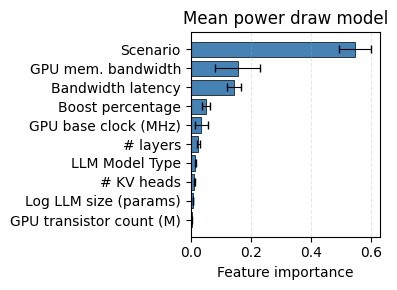

In [4]:
def collect_feature_importances(df, group_col, target_col, regressor, log_transform_y=False):
    """
    Run CV/LOGO/LOLO and return a DataFrame of feature importances per fold.
    Same internal logic as leave_one_out_cv_by_column, but returns importances 
    instead of predictions.
    
    Returns:
        pd.DataFrame with columns: ['fold', 'feature', 'importance']
    """
    df_result = df.copy()
    drop_cols = [c for c in [target_col, "gpu_db_name", "model", "thermal_design_power_w"] if c in df_result.columns]
    X = df_result.drop(columns=drop_cols)
    y = df_result[target_col]

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])

    if group_col is not None:
        groups = df_result[group_col]
        splits = LeaveOneGroupOut().split(X, y, groups)
    else:
        splits = KFold(n_splits=5, shuffle=True, random_state=42).split(X, y)

    importance_records = []
    for fold, (train_idx, _) in enumerate(splits, start=1):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        if log_transform_y:
            y_train = np.log(y_train)
        model_pipeline.fit(X_train, y_train)

        feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()

        if isinstance(regressor, XGBRegressor):
            importances = model_pipeline.named_steps['regressor'].feature_importances_
        elif hasattr(model_pipeline.named_steps['regressor'], 'coef_'):
            coefs = model_pipeline.named_steps['regressor'].coef_
            if coefs.ndim > 1:
                coefs = coefs.flatten()
            importances = np.abs(coefs)
        else:
            continue  # No importance to extract

        for feat, imp in zip(feature_names, importances):
            importance_records.append({
                "fold":       fold,
                "feature":    feat,
                "importance": float(imp),
            })

    return pd.DataFrame(importance_records)


def plot_feature_importance(importance_df, top_n=15, title="Feature importance", 
                              feature_name_map=None, ax=None, color="steelblue"):
    """
    Plot mean feature importance across folds with error bars showing variability.
    
    Args:
        importance_df: output of collect_feature_importances
        top_n: show only the top N features by mean importance
        title: plot title
        feature_name_map: dict mapping raw feature names to display names
        ax: optional matplotlib axis
        color: bar color
    """
    import matplotlib.pyplot as plt
    
    # Strip the "num__" / "cat__" preprocessor prefixes
    importance_df = importance_df.copy()
    importance_df["feature_clean"] = importance_df["feature"].str.replace(
        r"^(num__|cat__)", "", regex=True
    )
    
    # Apply optional pretty-name mapping
    if feature_name_map is not None:
        importance_df["feature_clean"] = importance_df["feature_clean"].map(
            lambda f: feature_name_map.get(f, f)
        )
    
    # Aggregate across folds
    agg = (importance_df
           .groupby("feature_clean")["importance"]
           .agg(["mean", "std"])
           .sort_values("mean", ascending=False)
           .head(top_n)
           .reset_index())
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, max(3, top_n * 0.3)))
    
    y_pos = np.arange(len(agg))
    ax.barh(y_pos, agg["mean"], xerr=agg["std"], 
            color=color, edgecolor="black", linewidth=0.5,
            error_kw={"linewidth": 0.8, "capsize": 3})
    ax.set_yticks(y_pos)
    ax.set_yticklabels(agg["feature_clean"])
    ax.invert_yaxis()  # most important on top
    ax.set_xlabel("Feature importance")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    
    return ax

# Collect importances under each evaluation strategy you care about
imp_power_logo = collect_feature_importances(
    df_clean, group_col="gpu_db_name", 
    target_col="normalized_power_draw", regressor=xgb
)

# Optional: pretty feature names for the paper
feature_names_pretty = {
    "total_b_params":          "LLM size (params)",
    "memory_bandwidth_gb_s":   "GPU mem. bandwidth",
    "tflops_16b":              "GPU FP16 TFLOPS",
    "memory_size_gb":          "GPU memory (GB)",
    "num_layers":              "# layers",
    "hidden_size":             "Hidden size",
    "num_attention_heads":     "# attention heads",
    "num_key_value_heads":     "# KV heads",
    "intermediate_size":       "Intermediate size",
    "release_year":            "GPU release year",
    "boost_percentage":        "Boost percentage",
    "bandwidth_latency":       "Bandwidth latency",
    "compute_latency_s":       "Compute latency",
    "max_batch_size":          "Max batch size",
    "scenario":                "Scenario",
    "model_type":              "LLM Model Type",
    "memory_type":             "GPU memory type",
    "transistor_count_m":       "GPU transistor count (M)",
    "base_clock_mhz":           "GPU base clock (MHz)",
    "log_total_b_params":       "Log LLM size (params)",
}

# Side-by-side plot for both models
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
plot_feature_importance(imp_power_logo, top_n=10,
                         title="Mean power draw model",
                         feature_name_map=feature_names_pretty,
                         ax=axes, color="steelblue")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

## Inter-Token Latency prediction (§5.2)

We train the ITL predictor with the feature set described in §4.2 — including the engineered max batch size and compute latency features — and evaluate it under 5-fold CV, LOGO, and LOLO. The XGBoost model is compared against a roofline-derived baseline that approximates ITL as the time to stream the LLM's FP16 weights from GPU memory once per token, with batch size 1 in server mode and the estimated max batch size in offline mode. The target is log-transformed during training because ITL spans several orders of magnitude across (LLM, GPU) pairs. The consolidated comparison table reproduces Table 3 in the paper.

In [5]:
# ---------------------------------------------------------------------------
# Roofline baseline and table helpers
# ---------------------------------------------------------------------------

def roofline_baseline_predictions(df, target_col):
    """Roofline ITL baseline: time to stream FP16 weights once per token.

    Computes T_bw = 2 * N_params / (B_mem * B), where B = 256 for offline rows
    and B = 1 for server rows. The 256 cap reflects vLLM's default
    --max-num-seqs scheduler limit, which bounds the effective batch size
    regardless of how much KV cache memory is available. The baseline has no
    learning step and is invariant to data splits.
    """
    pred_col = f"predicted_{target_col}"
    df_result = df.copy()

    VLLM_MAX_NUM_SEQS = 256
    batch_size = np.where(df_result["scenario"] == "offline", VLLM_MAX_NUM_SEQS, 1.0)

    df_result[pred_col] = (2.0 * df_result["total_b_params"]) / df_result["memory_bandwidth_gb_s"] / batch_size
    return df_result


def itl_results_table(df_xgb_cv, df_xgb_logo, df_xgb_lolo, df_clean, target_col):
    """Build the XGBoost (CV/LOGO/LOLO) vs. roofline-baseline table used in §5.2."""
    df_roofline = roofline_baseline_predictions(df_clean, target_col)

    parts = [
        evaluate_power(df_xgb_cv,    target_col, "CV",   "XGB"),
        evaluate_power(df_xgb_logo,  target_col, "LOGO", "XGB"),
        evaluate_power(df_xgb_lolo,  target_col, "LOLO", "XGB"),
        evaluate_power(df_roofline,  target_col, "—",    "Roofline"),
    ]
    full = pd.concat(parts, ignore_index=True)

    scenario_order = pd.CategoricalDtype(["Offline", "Server"], ordered=True)
    strategy_order = pd.CategoricalDtype(["CV", "LOGO", "LOLO", "—"], ordered=True)
    model_order    = pd.CategoricalDtype(["XGB", "Roofline"],          ordered=True)
    full["Scenario"] = full["Scenario"].astype(scenario_order)
    full["Strategy"] = full["Strategy"].astype(strategy_order)
    full["Model"]    = full["Model"].astype(model_order)

    return full.sort_values(["Model", "Scenario", "Strategy"]).reset_index(drop=True)


def format_itl_table(df_table):
    """Round and format ITL table values for paper-style display."""
    out = df_table.copy()
    out["MdAPE"]     = out["MdAPE"].map(lambda x:     f"{x:.1f}\\%")
    out["Pearson r"] = out["Pearson r"].map(lambda x: f"{x:.3f}")
    out["GPU τ"]     = out["GPU τ"].map(lambda x:     f"{x:.2f}")
    out["LLM τ"]     = out["LLM τ"].map(lambda x:     f"{x:.2f}")
    return out


def itl_table_to_latex(df_table, caption="ITL prediction performance.", label="tab:itl"):
    """Export the formatted ITL table as a LaTeX `table` environment."""
    formatted = format_itl_table(df_table)
    latex_body = formatted.to_latex(
        index=False,
        escape=False,
        column_format="llccccc",
    )
    return (
        f"\\begin{{table}}[t]\n"
        f"\\centering\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{{label}}}\n"
        f"{latex_body}"
        f"\\end{{table}}\n"
    )


# ---------------------------------------------------------------------------
# ITL prediction
# ---------------------------------------------------------------------------

# Features used to predict ITL. `gpu_db_name` and `model` are kept only for
# LOGO/LOLO grouping and dropped before training.
cols_for_itl = [
    'gpu_db_name',                  # LOGO grouping key, not a feature
    'model',                        # LOLO grouping key, not a feature
    'itl',                          # target

    # Workload features.
    'scenario',

    # LLM features.
    'model_type',
    'total_b_params',
    'hidden_size',
    'num_attention_heads',
    'num_key_value_heads',
    'num_layers',

    # GPU features.
    'memory_bandwidth_gb_s',
    'memory_size_gb',
    'memory_type',
    'tflops_16b',
    'release_year',

    # GPU-LLM pair features.
    'bandwidth_latency',
    #'max_concurrent_requests',
    'compute_latency_s',
]

target_col = "itl"
xgb = XGBRegressor(max_depth=5, reg_lambda=100, n_estimators=100)

# Clean the feature subset and drop rows with missing values.
df_clean = clean_df(df_all.loc[:, cols_for_itl])

print(f"Training XGBoost: {xgb}")

# Train and evaluate under all three strategies. Target is log-transformed
# because ITL spans several orders of magnitude across (LLM, GPU) pairs.
model_name = str(xgb).split('(')[0]
df_xgb_cv = leave_one_out_cv_by_column(
    df_clean, group_col=None, target_col=target_col,
    regressor=xgb, log_transform_y=True,
)

df_xgb_logo = leave_one_out_cv_by_column(
    df_clean, group_col="gpu_db_name", target_col=target_col,
    regressor=xgb, log_transform_y=True,
)

df_xgb_lolo = leave_one_out_cv_by_column(
    df_clean, group_col="model", target_col=target_col,
    regressor=xgb, log_transform_y=True,
)

# Build the consolidated table (XGBoost CV/LOGO/LOLO + roofline baseline) and export.
table = itl_results_table(
    df_xgb_cv, df_xgb_logo, df_xgb_lolo,
    df_clean,                       # full dataset, used by the baseline
    target_col=target_col,
)

print(format_itl_table(table).to_string(index=False))
print(itl_table_to_latex(
    table,
    caption=(
        "Inter-token latency prediction performance for XGBoost vs.\\ a "
        "roofline-derived baseline. The roofline baseline computes "
        "$T_{bw} = 2 N_{params} / B_{mem}$, the time to stream FP16 weights "
        "once; it is non-learning and therefore invariant to data splits."
    ),
    label="tab:itl_results",
))

Removed 50 rows with NaNs
Training XGBoost: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
   Model Scenario Strategy  MdAPE Pearson r GPU τ LLM τ
     XGB  Offline       CV 12.8\%     0.813  0.86  0.81
     XGB  Offline     LOGO 24.9\%     0.727  0.72  0.83
     XGB  Offline     LOLO 15.6\%     0.80

### Feature importances for ITL

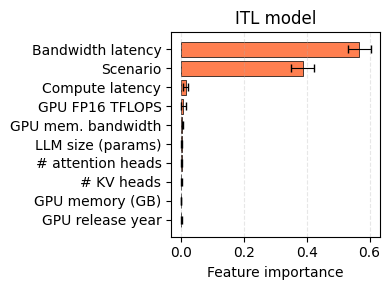

In [6]:
# Side-by-side plot for both models
import matplotlib.pyplot as plt
imp_itl_logo = collect_feature_importances(
    df_clean, group_col="gpu_db_name", 
    target_col="itl", regressor=xgb
)
fig, axes = plt.subplots(1, 1, figsize=(4, 3))
plot_feature_importance(imp_itl_logo, top_n=10,
                         title="ITL model",
                         feature_name_map=feature_names_pretty,
                         ax=axes, color="coral")
plt.tight_layout()
plt.savefig("feature_importance_itl.png", dpi=300, bbox_inches="tight")